# GW Turbulence — Full Workflow Demo

A self-contained walkthrough of the `gw_turbulence` library: from evaluating kernel functions to computing and saving 2D spectral grids. Run this notebook from the `src/` directory.

In [14]:
import time
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

from gw_turbulence import (
    g_decaying,
    H_k0_analytic,
    H_pq,
    H_pq_decaying,
    H_pq_decaying_grid,
    LiveStatusLogger,
    mpi_is_active,
    plot_spectra_M_analytic,
)

%matplotlib inline

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)

## 1. Core kernel functions

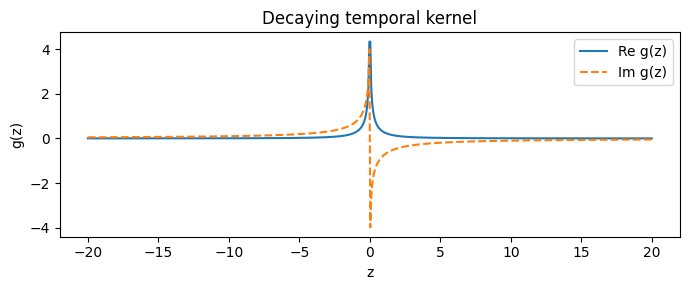

g(-z) == conj(g(z)):  True
max |g|: 5.8973


In [15]:
z = np.linspace(-20, 20, 600)
gz = g_decaying(z)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(z, gz.real, label='Re g(z)')
ax.plot(z, gz.imag, label='Im g(z)', linestyle='--')
ax.set_xlabel('z')
ax.set_ylabel('g(z)')
ax.set_title('Decaying temporal kernel')
ax.legend()
fig.tight_layout()
plt.show()

print(f'g(-z) == conj(g(z)):  {np.allclose(g_decaying(-z), np.conj(gz))}')
print(f'max |g|: {np.abs(gz).max():.4f}')

## 2. Analytic p→0 spectrum (fast)

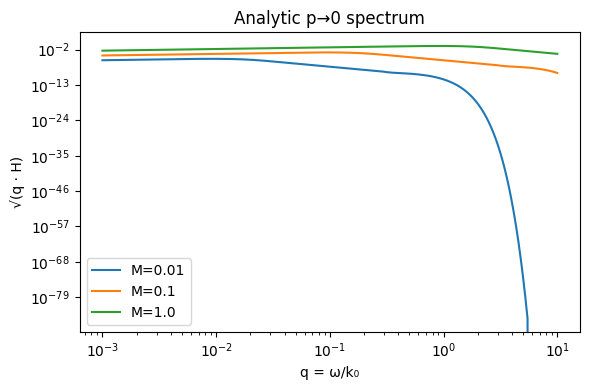

In [16]:
qs = np.logspace(-3, 1, 200)
M_values = [0.01, 0.1, 1.0]

fig, ax = plt.subplots(figsize=(6, 4))
for M in M_values:
    H = H_k0_analytic(qs, M=M)
    ax.loglog(qs, np.sqrt(qs * H), label=f'M={M}')

ax.set_xlabel('q = ω/k₀')
ax.set_ylabel('√(q · H)')
ax.set_title('Analytic p→0 spectrum')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Single-point evaluation: stationary vs decaying

In [17]:
p, q, M, R, k0 = 0.5, 0.3, 0.1, 1e3, 1.0

t0 = time.perf_counter()
H_stat = H_pq(p, q, M=M, R=R, k0=k0, epsabs=5e-4, epsrel=3e-3)
t_stat = time.perf_counter() - t0

status = LiveStatusLogger(prefix='single-pt', every_seconds=0.0)
t0 = time.perf_counter()
H_dec = H_pq_decaying(
    p, q, M=M, R=R, k0=k0,
    convolution_method='trapz', convolution_points=32,
    integration_method='sampled', x_points=12, y_points=12,
    status=status,
)
t_dec = time.perf_counter() - t0

print(f'H_stationary(p={p}, q={q}) = {H_stat:.6g}  ({t_stat:.3f} s)')
print(f'H_decaying  (p={p}, q={q}) = {H_dec:.6g}  ({t_dec:.3f} s)')

[single-pt] start H_pq_decaying p=5.000e-01 q=3.000e-01 M=1.000e-01 conv=trapz integ=sampled
[single-pt]   x-step 1/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 2/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 3/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 4/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 5/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 6/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 7/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 8/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 9/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 10/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 11/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 12/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 13/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 14/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 15/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 16/16 for p=5.000e-01, q=3.000e-01
[single-pt] done H_p

## 4. Coarse 2D grids

In [18]:
ps = np.logspace(-2, 0, 8)
qs = np.logspace(-2, 0, 8)
M, R, k0 = 0.1, 100.0, 1.0

# Stationary grid
H_stationary = np.zeros((len(qs), len(ps)))
for i, q in enumerate(qs):
    for j, p in enumerate(ps):
        H_stationary[i, j] = H_pq(p, q, M=M, R=R, k0=k0, epsabs=5e-4, epsrel=3e-3)

print('Stationary grid done.')

# Decaying grid
status = LiveStatusLogger(prefix='coarse-grid', every_seconds=2.0)
H_decaying = H_pq_decaying_grid(
    ps, qs, M=M, R=R, k0=k0,
    verbose=True,
    convolution_method='trapz', convolution_points=32,
    integration_method='sampled', x_points=12, y_points=12,
    status=status, log_points=True,
    use_mpi=False, processes=8,
)

print('Decaying grid done.')

Stationary grid done.
[coarse-grid] grid start rows=8 cols=8 M=1.000e-01 method=trapz points=32 rank=1/1
[coarse-grid] using multiprocessing with 8 workers
[coarse-grid] row 1/8 complete
[coarse-grid] row 8/8 complete
[coarse-grid] row 4/8 complete
[coarse-grid] row 5/8 complete
[coarse-grid] row 6/8 complete
[coarse-grid] row 2/8 complete
[coarse-grid] row 7/8 complete
[coarse-grid] row 3/8 complete
[coarse-grid] grid complete
Decaying grid done.


## 5. Side-by-side comparison

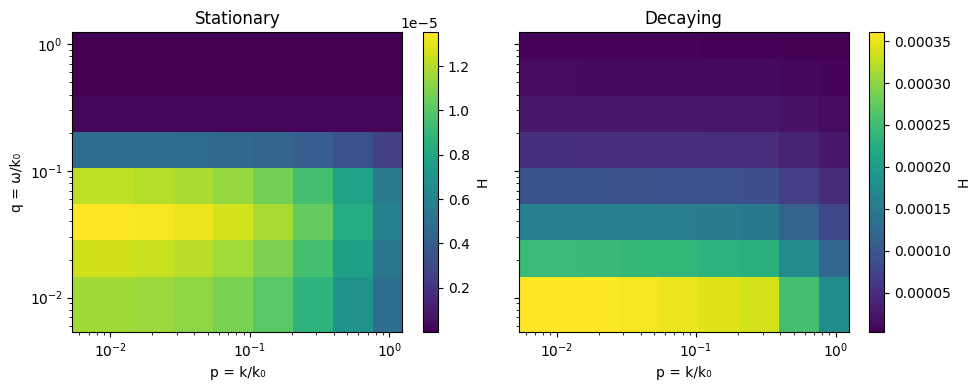

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

pcm1 = ax1.pcolormesh(ps, qs, H_stationary, shading='auto', cmap='viridis')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('p = k/k₀')
ax1.set_ylabel('q = ω/k₀')
ax1.set_title('Stationary')
fig.colorbar(pcm1, ax=ax1, label='H')

pcm2 = ax2.pcolormesh(ps, qs, H_decaying, shading='auto', cmap='viridis')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('p = k/k₀')
ax2.set_title('Decaying')
fig.colorbar(pcm2, ax=ax2, label='H')

fig.tight_layout()
plt.show()

## 6. Save and reload a grid (.npz)

In [20]:
save_path = os.path.join(out_dir, 'demo_grid.npz')
np.savez(save_path, ps=ps, qs=qs, H=H_stationary)
print(f'Saved: {save_path}')

data = np.load(save_path)
ps_loaded = data['ps']
qs_loaded = data['qs']
H_loaded  = data['H']

assert np.allclose(ps_loaded, ps), 'ps mismatch'
assert np.allclose(qs_loaded, qs), 'qs mismatch'
assert np.allclose(H_loaded, H_stationary), 'H mismatch'
print('Round-trip verification passed.')

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/demo_grid.npz
Round-trip verification passed.


## 7. Library plotting helpers

Wrote /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/demo_analytic_Ms1.00em02-1.00em01-1.00ep00_R1.00ep04.png


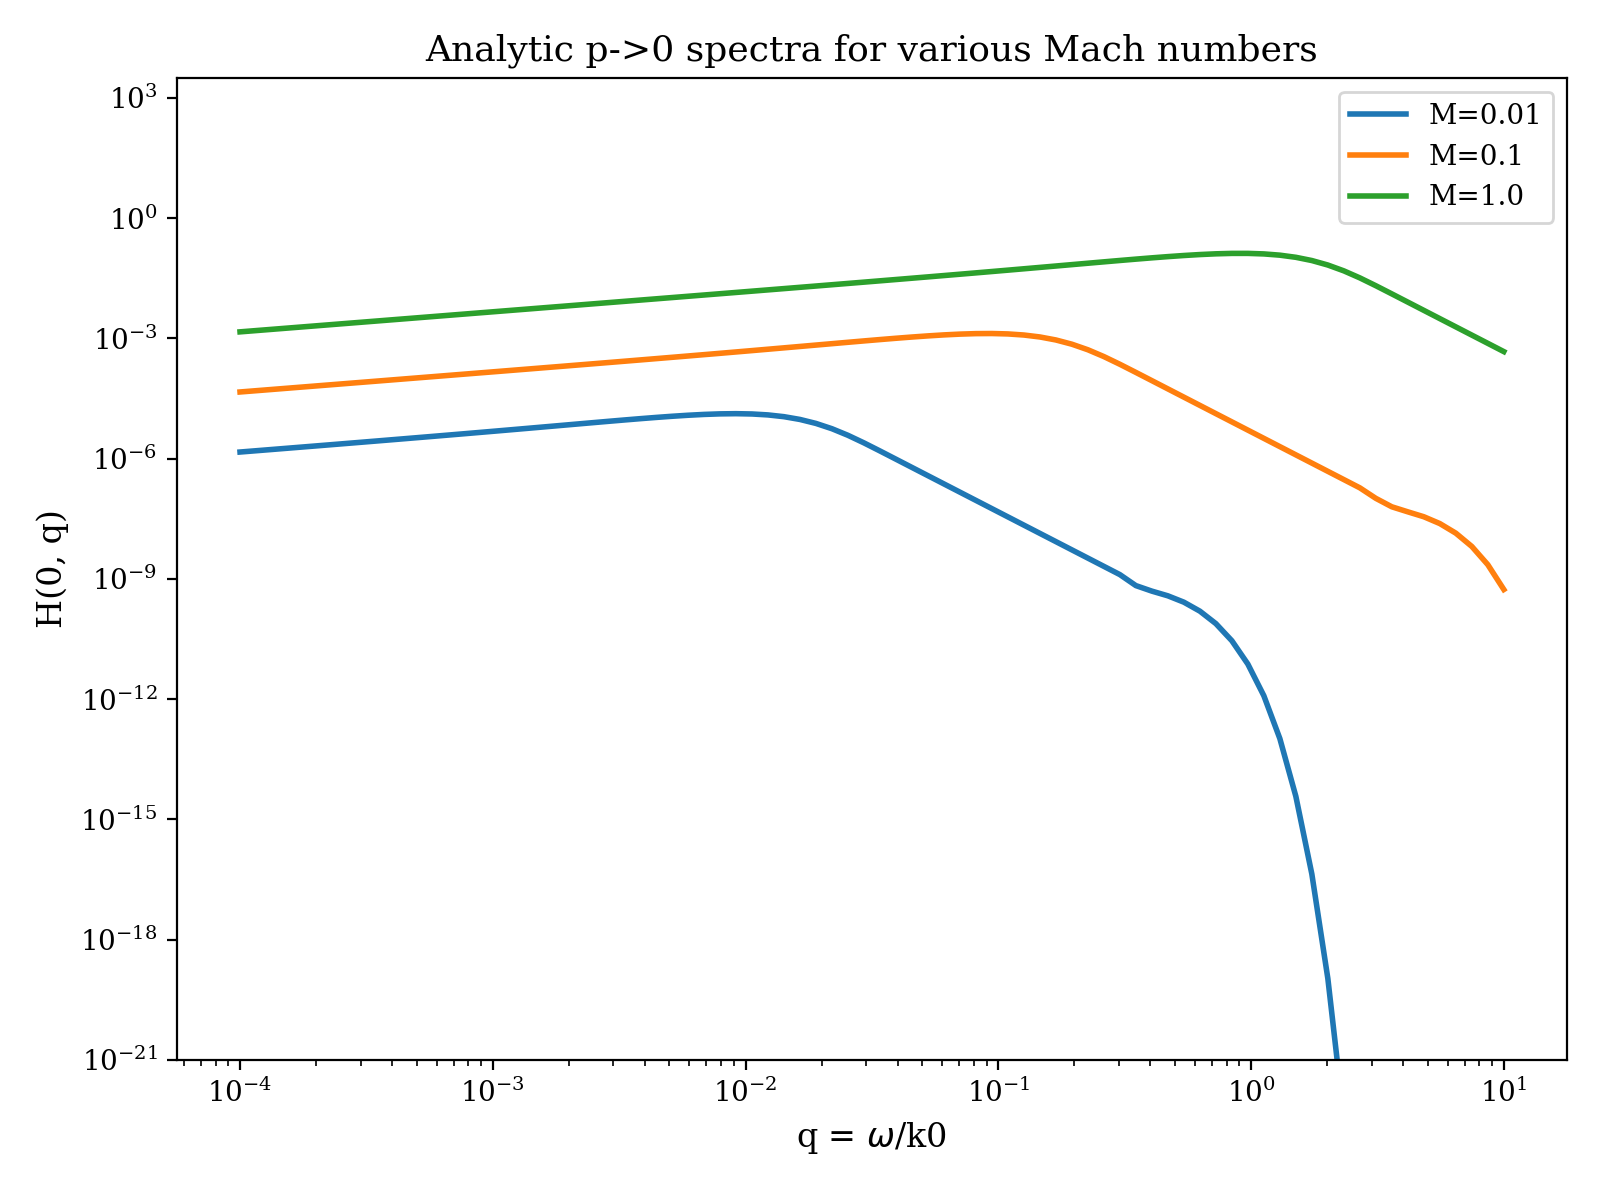

In [21]:
out_png = os.path.join(out_dir, 'demo_analytic.png')
plot_spectra_M_analytic([0.01, 0.1, 1.0], nq=80, R=1e4, out_png=out_png)

# Reconstruct the actual filename the helper writes
M_list = [0.01, 0.1, 1.0]
mlist_str = '-'.join([f"{M:.2e}".replace('+', 'p').replace('-', 'm') for M in M_list])
rstr = f"{1e4:.2e}".replace('+', 'p').replace('-', 'm')
base, ext = os.path.splitext(out_png)
actual_png = f"{base}_Ms{mlist_str}_R{rstr}{ext}"

if os.path.exists(actual_png):
    display(Image(filename=actual_png))
else:
    # Fall back: show whichever PNG was just created
    print(f'Expected: {actual_png}')
    pngs = sorted([f for f in os.listdir(out_dir) if 'demo_analytic' in f])
    for fn in pngs:
        display(Image(filename=os.path.join(out_dir, fn)))

## 8. Gogoberidze 2007 Fig. 1 — stationary turbulence reproduction

The central result of Gogoberidze et al. (2007) is an analytic expression for the
gravitational-wave characteristic strain from **stationary** Kolmogorov turbulence.
The derivation proceeds in three steps:

**Step 1 — stress tensor correlator:**  
The GW source is the transverse-traceless part of the turbulent stress tensor.
Its two-point function in Fourier space is

$$H_{ijij}(\mathbf{k},\omega)
= \frac{1}{(2\pi)^8}
\int d^3k_1\,d\omega_1\;
\tilde{F}_{ii}(\mathbf{k}_1,\omega_1)\,\tilde{F}_{jj}(\mathbf{k}{-}\mathbf{k}_1,\omega{-}\omega_1)
+ \tfrac{1}{3}\tilde{F}_{ij}\tilde{F}_{ij}$$

**Step 2 — geometric kernel:**  
After substituting the isotropic Kolmogorov spectrum and evaluating the projection
contractions, the angular integral over the direction of $\mathbf{k}_1$ can be done
analytically, yielding the geometric bracket

$$\mathcal{K}(p,x,y) =
27 - p^2 x^{3/2} - p^2 y^{3/2}
+ \tfrac{p^4}{2}x^{3/2}y^{3/2}
+ \tfrac{1}{2}x^{-3/2}y^{3/2}
+ \tfrac{1}{2}y^{-3/2}x^{3/2}$$

where $x=(k_1/k_0)^{-4/3}$, $y=(u/k_0)^{-4/3}$, $p=k/k_0$ (implemented as `kernel_bracket`).

**Step 3 — temporal convolution via erfc:**  
The stationary temporal function $f(\eta_k,\tau)=\exp(-\tfrac{\pi}{4}\eta_k^2\tau^2)$
has a Gaussian Fourier transform, so the $\omega_1$ convolution integral can be done
analytically via the complementary error function, giving the closed-form `H_pq(p,q)`.

Below we reproduce Fig. 1 of Gogoberidze et al. (2007): the exact result `H_pq(q,q)` (solid)
vs. the analytic $p\to 0$ approximation `H_k0_analytic(q)` (dotted), for three Mach numbers
$M = 0.01,\,0.1,\,1.0$.

In [ ]:
# Reproduce Gogoberidze et al. (2007) Fig. 1 — stationary turbulence
# Solid: H_pq(q, q) exact.   Dotted: H_k0_analytic(q) analytic p→0 approx.

from gw_turbulence import kernel_bracket, plot_gogoberidze_2007_figure1

M_list = [0.01, 0.1, 1.0]
nq = 50
R, k0 = 1e4, 1.0
qs = np.logspace(np.log10(1e-5), np.log10(64.0), nq)
scaled_freq = 1.55e-3 * qs          # physical frequency axis (Gogoberidze normalization)

print('kernel_bracket(p=1, x=1, y=1) =', kernel_bracket(1.0, 1.0, 1.0),
      '   (expected 26.5 = 27 − 1 − 1 + 0.5 + 0.5 + 0.5)')

fig, ax = plt.subplots(figsize=(7, 5))
for M in M_list:
    exact = np.zeros(nq)
    aero  = np.zeros(nq)
    for i, q in enumerate(qs):
        exact[i] = H_pq(q, q, M=M, R=R, k0=k0, epsabs=1e-4, epsrel=1e-3)
        aero[i]  = H_k0_analytic(q, M=M, k0=k0, R=R)

    # Gogoberidze normalization: divide by M^{3/2} and multiply by overall factor
    scaled_exact = 1.62e-18 * np.sqrt(np.clip(qs * exact, 0.0, None)) / M**1.5
    scaled_aero  = 1.62e-18 * np.sqrt(np.clip(qs * aero,  0.0, None)) / M**1.5

    ax.loglog(scaled_freq, scaled_exact, color='black', lw=1.5)
    ax.loglog(scaled_freq, scaled_aero,  color='black', lw=1.0, ls=':')

ax.set_xlim(1e-8, 1e-1)
ax.set_ylim(1e-23, 1e-19)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$',
              fontsize=10)
ax.set_ylabel(r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$',
              fontsize=10)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()

# Save via the library helper and display the result
gogoberidze_png = os.path.join(out_dir, 'gogoberidze_2007_fig1.png')
plot_gogoberidze_2007_figure1(
    M_list=(0.01, 0.1, 1.0), nq=50, R=1e4, k0=1.0,
    out_png=gogoberidze_png, epsabs=1e-4, epsrel=1e-3,
)

# Reconstruct the actual filename the helper writes
mlist_str = '-'.join([f"{M:.2e}".replace('+', 'p').replace('-', 'm') for M in (0.01, 0.1, 1.0)])
rstr = f"{1e4:.2e}".replace('+', 'p').replace('-', 'm')
base, ext = os.path.splitext(gogoberidze_png)
actual_gogo_png = f"{base}_Ms{mlist_str}_R{rstr}{ext}"
if os.path.exists(actual_gogo_png):
    display(Image(filename=actual_gogo_png))

## 9. Decaying turbulence — Gogoberidze-style comparison

For **decaying** turbulence the energy spectrum evolves in time: $E(t) \propto (1 + t/\tau_1)^{-2/3}$.
This replaces the stationary Gaussian temporal profile with a power-law decay.
The key difference appears in the single-mode temporal function:

$$\tilde{g}(\omega) = e^{i\omega\tau_1}(-i\omega\tau_1)^{-1/3}\,\Gamma\!\left(\tfrac{1}{3},\,-i\omega\tau_1\right)$$

implemented as `g_decaying(z)` with $z = \omega\tau_1$ (upper incomplete Gamma function).

Because $\tilde{g}$ is no longer Gaussian, the $\omega_1$ convolution integral must be done
**numerically** (trapz over a cosine-spaced grid), making `H_pq_decaying` significantly more
expensive than `H_pq`. The same geometric kernel $\mathcal{K}(p,x,y)$ applies, so both models
can be compared on identical normalized axes.

Below: diagonal $p = q$ for $M = 0.1$ and $M = 1.0$ — **solid** = stationary, **dashed** = decaying.

*(Coarse integration settings for speed; increase `x_points`, `y_points`, `convolution_points`,
and `nq` for publication-quality results.)*

In [ ]:
# Decaying vs stationary comparison on Gogoberidze-style normalized axes (p = q diagonal)
# Coarse settings — increase nq / x_points / y_points for higher accuracy

M_compare = [0.1, 1.0]
nq_dec = 16                      # keep low: each decaying point is expensive
R_dec, k0_dec = 1e3, 1.0
qs_dec = np.logspace(np.log10(1e-4), np.log10(10.0), nq_dec)
scaled_freq_dec = 1.55e-3 * qs_dec

status = LiveStatusLogger(prefix='decay-cmp', every_seconds=5.0)
colors = {0.1: 'C0', 1.0: 'C2'}

fig, ax = plt.subplots(figsize=(8, 5))

for M in M_compare:
    h_stat = np.zeros(nq_dec)
    h_dec  = np.zeros(nq_dec)

    for i, q in enumerate(qs_dec):
        h_stat[i] = H_pq(q, q, M=M, R=R_dec, k0=k0_dec, epsabs=1e-4, epsrel=1e-3)

    for i, q in enumerate(qs_dec):
        h_dec[i] = H_pq_decaying(
            q, q, M=M, R=R_dec, k0=k0_dec,
            convolution_method='trapz', convolution_points=48,
            integration_method='sampled', x_points=16, y_points=16,
            status=status,
        )

    sc_stat = 1.62e-18 * np.sqrt(np.clip(qs_dec * h_stat, 0.0, None)) / M**1.5
    sc_dec  = 1.62e-18 * np.sqrt(np.clip(qs_dec * h_dec,  0.0, None)) / M**1.5

    ax.loglog(scaled_freq_dec, sc_stat, color=colors[M], lw=2.0,
              label=f'stationary  $M={M}$')
    ax.loglog(scaled_freq_dec, sc_dec,  color=colors[M], lw=1.5, ls='--',
              label=f'decaying    $M={M}$')

ax.set_xlim(1e-8, 1e-1)
ax.set_ylim(1e-23, 1e-19)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$',
              fontsize=10)
ax.set_ylabel(r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$',
              fontsize=10)
ax.set_title('Stationary vs decaying turbulence (Gogoberidze-normalized axes)\n'
             r'Diagonal $p = q$,  $M = 0.1,\,1.0$',
             fontsize=11)
ax.legend(fontsize=9, ncol=2)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()

dec_cmp_png = os.path.join(out_dir, 'stationary_vs_decaying_gogoberidze_norm.png')
fig.savefig(dec_cmp_png, dpi=150)
print(f'Saved: {dec_cmp_png}')